<a href="https://colab.research.google.com/github/pradeep0153/AlgoBuddy/blob/main/Net_flix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("netflix_titles.csv.zip")

In [ ]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [ ]:
df.shape

(8807, 12)

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [ ]:
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [ ]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
df = df.dropna()


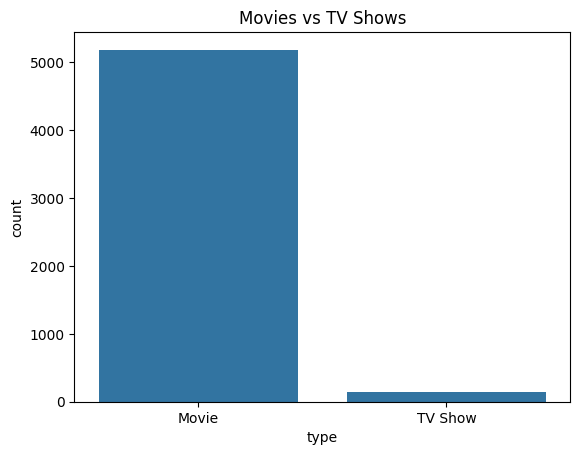

In [ ]:
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.show()

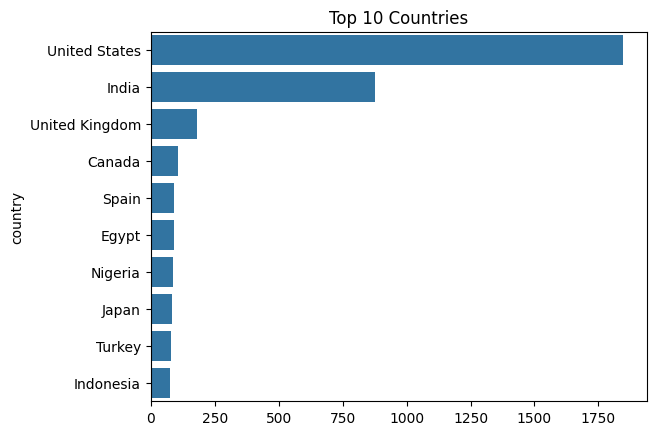

In [ ]:
top_country = df["country"].value_counts().head(10)

sns.barplot(x=top_country.values,
            y=top_country.index)

plt.title("Top 10 Countries")
plt.show()

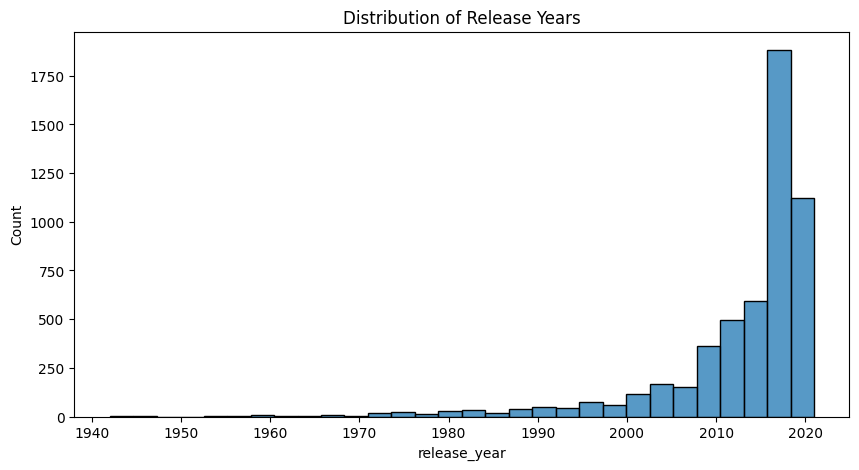

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df["release_year"], bins=30)

plt.title("Distribution of Release Years")
plt.show()

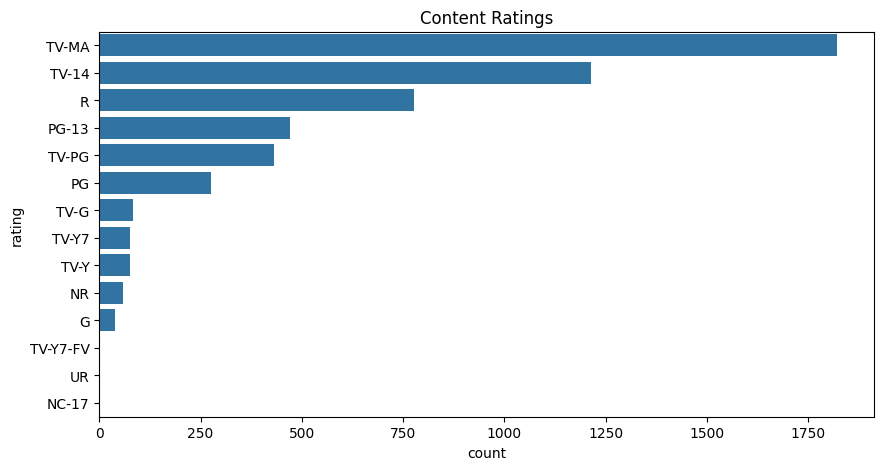

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              y="rating",
              order=df["rating"].value_counts().index)

plt.title("Content Ratings")
plt.show()

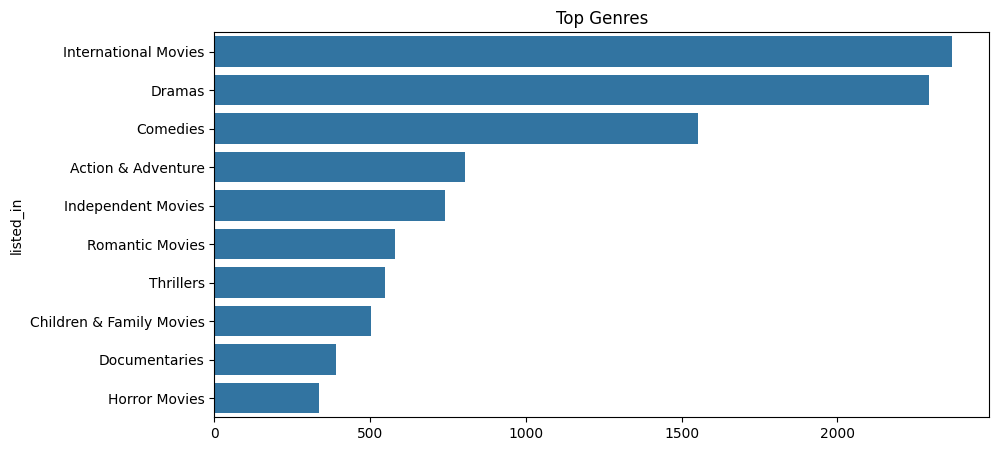

In [ ]:
genre = df["listed_in"].str.split(", ").explode()

top_genres = genre.value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_genres.values,
            y=top_genres.index)

plt.title("Top Genres")
plt.show()

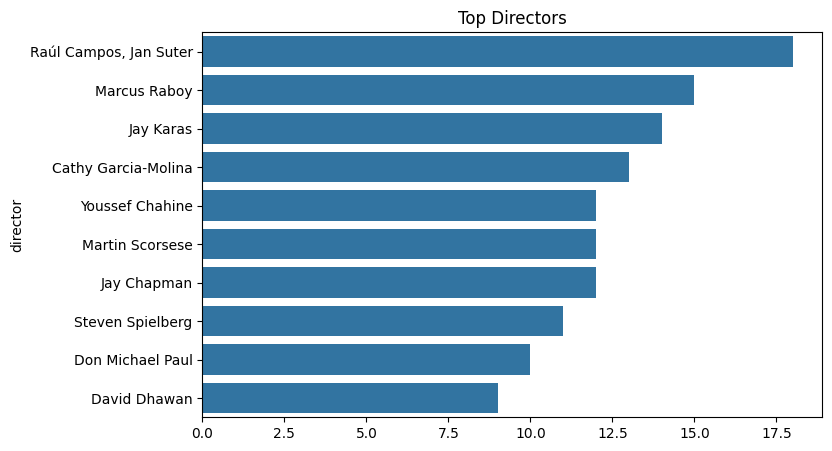

In [ ]:
director = df["director"].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(x=director.values,
            y=director.index)

plt.title("Top Directors")
plt.show()

In [ ]:
movies = df[df["type"]=="Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min","").astype(int)

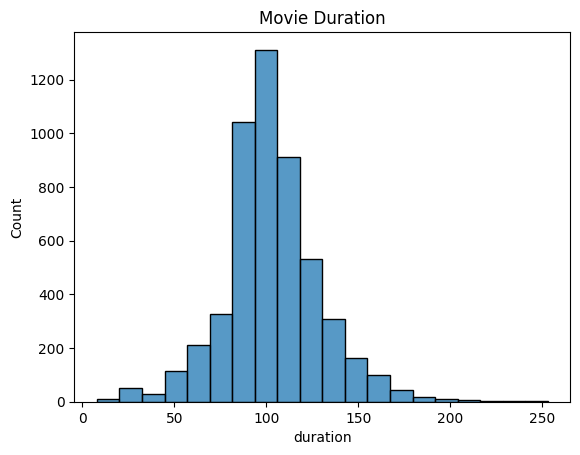

In [ ]:
sns.histplot(movies["duration"], bins=20)

plt.title("Movie Duration")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv("netflix_titles.csv.zip")

In [ ]:
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [ ]:
df = df[['title', 'director', 'cast', 'listed_in', 'description']]

In [ ]:
df.fillna('', inplace=True)

In [ ]:
df["combined_features"] = (
    df["director"] + " " +
    df["cast"] + " " +
    df["listed_in"] + " " +
    df["description"]
)

In [ ]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df["combined_features"])

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix)

In [ ]:
indices = pd.Series(df.index, index=df["title"]).drop_duplicates()

In [ ]:
def recommend(title, cosine_sim=cosine_sim):

    # Get the index of the selected title
    idx = indices[title]

    # Get similarity scores with all other titles
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity (highest first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Ignore the first result (it is the same title)
    sim_scores = sim_scores[1:6]

    # Extract movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return recommended titles
    return df["title"].iloc[movie_indices]

In [ ]:
print(recommend("Dark"))

260                      The Defeated
626     Sophie: A Murder in West Cork
4508                    Stunt Science
1294                 Tribes of Europa
1335                       The Sinner
Name: title, dtype: object


In [ ]:
def recommend_by_genre(genre, n=10):
    # Filter titles that contain the given genre
    result = df[df["listed_in"].str.contains(genre, case=False, na=False)]

    # Return only the title column
    return result["title"].head(n)

In [ ]:
print(recommend_by_genre("Comedy"))

278                          Lokillo: Nothing's the Same
359                         The Original Kings of Comedy
388              Plastic Cup Boyz: Laughing My Mask Off!
400    Revelations: The Masters of the Universe: Reve...
475                                         The Stand-Up
484                         Lee Su-geun: The Sense Coach
511                                              Chelsea
744                                          Locombianos
766                              Alan Saldaña: Locked Up
826                                   Bo Burnham: Inside
Name: title, dtype: object


In [ ]:
print(recommend_by_genre("Horror"))

5          Midnight Mass
28            Dark Skies
42                Jaws 2
43                Jaws 3
44     Jaws: The Revenge
200      Krishna Cottage
210           Ragini MMS
211         Ragini MMS 2
229         The Old Ways
236              Boomika
Name: title, dtype: object
